# Pathway Mining

## 1. Introduction

### This Chapter
In this chapter, we explore **pathway mining**—the use of network science and reasoning algorithms to uncover sequential patterns leading to specific outcomes. This is especially relevant in domains like **medicine** and **education**, where events unfold in a series of steps, such as disease progression or course completion.

We’ll focus on an educational example involving medical school students, using simulated data to identify sequences of courses that lead to success or failure. This helps pinpoint where struggling students may need support.

You’ll learn how to:

* Recognize problems involving sequential pathways
* Apply Bayesian networks and causal reasoning to analyze these paths
* Use conditional probabilities and Bayes’ Theorem to estimate the likelihood of outcomes
* Intervene at key steps to improve success rates

While our focus is on education, the same techniques apply to various fields—such as understanding drug addiction pathways, machinery failure cascades, or logistics chains.

### Causal pathways
Causal pathways are sequences of events connected by conditional probabilities, forming chains that explain how an outcome occurs. These can range from simple to highly complex, like those in biological systems. Using Bayes’ Theorem, we can link these events step-by-step to estimate the likelihood of outcomes. When the exact event sequence is unknown, we rely on algorithms—such as Bayesian networks—to uncover and analyze these hidden pathways in the data.


### Bayesian Networks and the Chain Rule

A Bayesian network is a directed acyclic graph (DAG) that represents variables and their conditional dependencies. Unconnected nodes are conditionally independent, while connected ones are dependent. Using the chain rule of probability, we can express the joint probability of events (e.g., drug use stages) as a product of conditional probabilities, such as:

$$
P(A, B, C) = P(A|B, C) \cdot P(B|C) \cdot P(C)
$$

Since these probabilities are usually inferred from data, we use algorithms like expectation-maximization (EM) to estimate them. EM iteratively computes expected values and maximizes the likelihood until the results converge.

With this foundation, we can now explore how Bayesian networks are applied to educational data and pathway discovery.


### The dataset

Educational systems often follow structured pathways, where success in advanced courses depends on prior knowledge from foundational ones. This makes Bayesian networks a natural fit for analyzing course sequences and identifying key factors that influence student outcomes.

In this notebook, we explore a simplified example inspired by a medical education program. We'll simulate data where student success in later courses—and ultimately graduation—depends on performance in earlier, prerequisite courses. Using a prior-knowledge approach, we’ll demonstrate how Bayesian networks can reveal the relationships between courses and help us understand critical pathways to educational success.




## 2. Analysis

### Generate Simulation using Binomial distribution for class success

In [1]:
#import needed packages
import pandas as pd
import numpy as np

In [2]:
#create conditional courses that relate to final exam passage rates

#course 1, with low passage rates in general
course1=np.random.binomial(1,0.75,500)

#course 2, with low passage rates on the first attempt if course 1 was failed
course2a=np.random.binomial(1,0.95,500)
course2b=np.random.binomial(1,0.5,500)
course2=np.where(course1>0,course2a,course2b)

#course 3, with passage rates relative dependent on prior performance
course3a=np.random.binomial(1,0.95,500)
course3b=np.random.binomial(1,0.65,500)
course3=np.where(course2+course1>1,course3a,course3b)

In [3]:
#create two other courses that are not related to performance on final exam
course4=np.random.binomial(1,0.8,200)
course5=np.random.binomial(1,0.85,200)

In [10]:
#create final exam passage rates
passa=np.random.binomial(1,0.95,200)
passb=np.random.binomial(1,0.75,200)

pass_final=np.where(course1+course2+course3>2,course3a,course3b)

In [11]:
Course_Data=pd.DataFrame([course1,course2,course3,course4,course5,pass_final],
                        index=['Course_1','Course_2','Course_3','Course_4',
                              'Course_5','Pass_Final_Exam']).transpose()

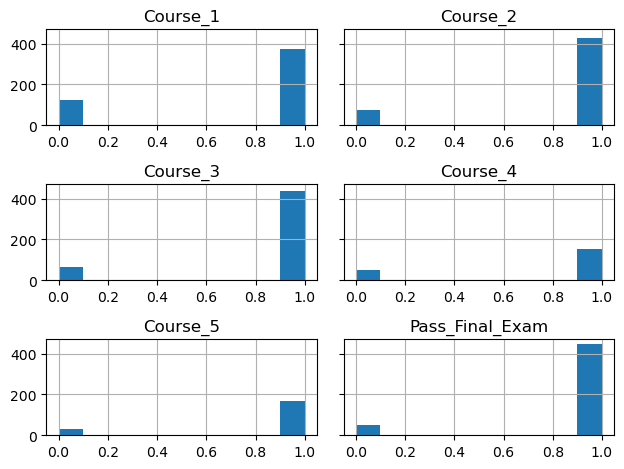

In [17]:

import matplotlib.pyplot as plt;
Course_Data.hist(sharey=True);plt.tight_layout()

### Run Bayesian network analysis 

In [18]:
#install bnlearn package if not already in directory and import
#!pip install -U bnlearn
import bnlearn as bn

In [22]:
#fit Bayesian network
model = bn.structure_learning.fit(Course_Data)

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [23]:
model['adjmat']

target,Course_1,Course_2,Course_3,Course_4,Course_5,Pass_Final_Exam
source,,,,,,
Course_1,False,True,False,False,False,False
Course_2,False,False,False,False,False,False
Course_3,False,False,False,False,False,True
Course_4,False,True,False,False,False,True
Course_5,True,False,True,False,False,False
Pass_Final_Exam,True,False,False,False,False,False


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


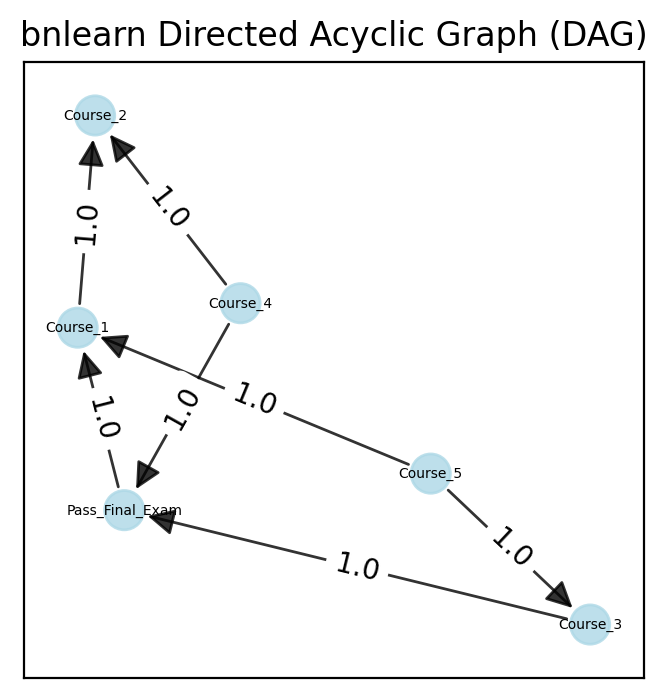

In [58]:
#plot Bayesian network derived from dataset
fig = bn.plot(model,node_size=200,params_static={'figsize': (4, 4),'font_size':5})

### A second Bayesian network with different fitting algorithm

In [59]:
#fit Bayesian network
model = bn.structure_learning.fit(Course_Data.iloc[:,0:3], methodtype='ex')

[bnlearn] >Computing best DAG using [ex]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [60]:
model['adjmat']

target,Course_1,Course_2,Course_3
source,,,
Course_1,False,True,True
Course_2,False,False,True
Course_3,False,False,False


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


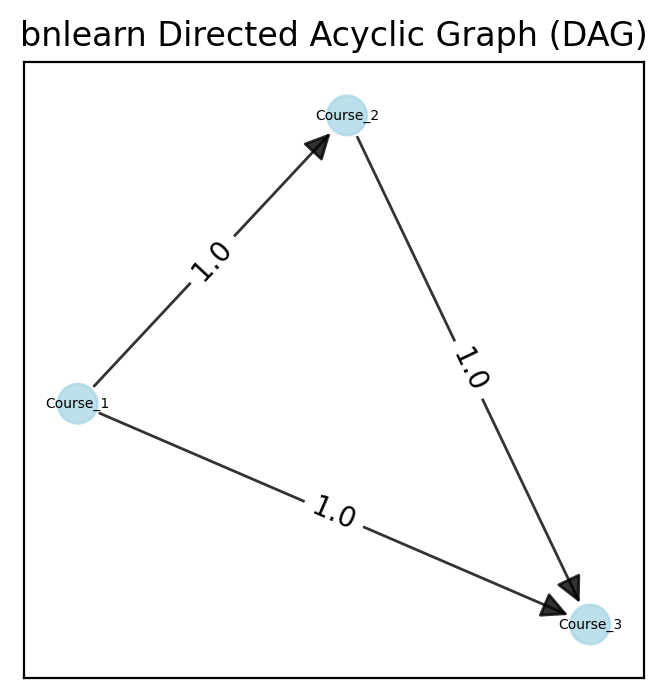

In [61]:
#plot Bayesian network derived from dataset
fig = bn.plot(model,node_size=200,params_static={'figsize': (4, 4),'font_size':5})

# Conclusion

These tools provided a starting point for collecting additional data that could be analyzed to confirm hypotheses constructed from Bayesian networks through a class of models called SEMs.